<a href="https://colab.research.google.com/github/Kevin-AngelQD/padp/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo_271758.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Kevin Angel Quiñonez Dominguez
- **Matrícula:** 271758

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [2]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.

print("Media: ",df['price'].mean())
print("Mediana: ",df['price'].median())
print("Moda: ",df['price'].mode())


Media:  152.7206871868289
Mediana:  106.0
Moda:  0    100
Name: price, dtype: int64


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_ Divergen considerablemente. Podemos determinar que tiene un outlier o mas.

---
## Actividad 2 — Dispersión (20 pts)

In [3]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.
print("Rango: ",df['price'].max() - df['price'].min())
print("Varianza: ",df['price'].var())
print("Desviacion estandar: ",df['price'].std())


Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1 (percentil 25): {Q1:,.2f}')
print(f'Q3 (percentil 75): {Q3:,.2f}')
print(f'IQR:                {IQR:,.2f}')
#print(df['price'].max())#10000
#print(df['price'].min())#0


Rango:  10000
Varianza:  57674.02524696084
Desviacion estandar:  240.15416974718727
Q1 (percentil 25): 69.00
Q3 (percentil 75): 175.00
IQR:                106.00


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_ Considero que seria el IQR, el valor maximo es 10000 y el minimo es 0, tomando en cuenta esto, seria un rango de 10000, tomando en cuenta el IQR y la cercania a valores centrales, lo tomaria mas representativo. 10000 es un outlier

---
## Actividad 3 — Forma (20 pts)

In [4]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
print("Asimetria: ",df['price'].skew())
print("Curtosis: ",df['price'].kurt())



Asimetria:  19.118938995046033
Curtosis:  585.6728788988286


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_ En comparacion con `Income` y `price` podemos determinar que:

-En asimetria: La cola se alargo tres veces mas, osea un sesgo positivo extremo. Los precios altos jalan la distribución con una fuerza gigante.

-En curtosis: Distribución Leptocúrtica extrema. El pico central es ultra alto y las colas son pesadísimas. Indica una presencia masiva de outliers extremos.

La asimetría mide la falta de simetría. Al ser un valor positivo, te dice que la cola larga está a la derecha (valores altos). Si la mayoría de los precios están cerca de $100 con un outlier de 10000 y un minimo de 0 (10000-0) elevada al cubo da un número absurdamente gigantesco. Un solo outlier muy lejano altera por completo la asimetría hacia el lado positivo.

$\sum (X - \mu)^3$


La curtosis mide el "espesor" de las colas, es decir, qué tan probable es encontrar valores muy lejos del centro.

Elevar a la cuarta potencia penaliza de forma destructiva a los valores atípicos. Si el valor de 10,000 ya afectaba a la asimetría, en la curtosis se multiplica por sí mismo cuatro veces. 585.67 es un síntoma inequívoco de que el DataFrame actual tiene valores máximos que son "monstruos" en comparación con el resto de los datos (el Q3 era de apenas $175).

$\sum (X - \mu)^4$


---
## Actividad 4 — Visualización (30 pts)

<Axes: ylabel='Frequency'>

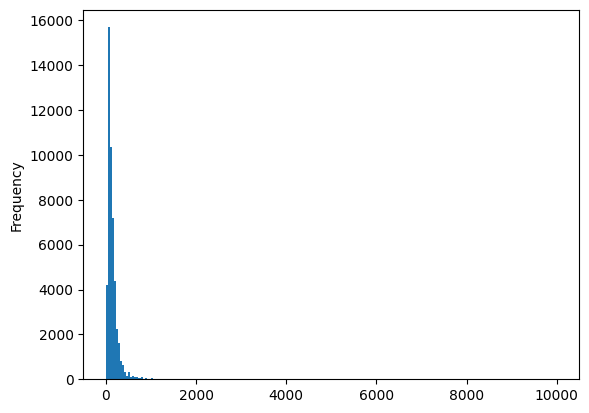

In [5]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.
#print("Rows:", df.shape[0]) #48895
#print("Columns:", df.shape[1]) # 16
df['price'].plot(kind='hist', bins=221)

#Intente con 10 pero solo parecia una barra, despues de investigar que tantos datos
#se estan manejando trate de usar la regla de Sturges (17 bins) pero esta mostraba
#todos los datos en una barra masiva, decidi ir con la regla de la raiz cuadrada para
#que se pueda apreciar al "monstruo" de 10000


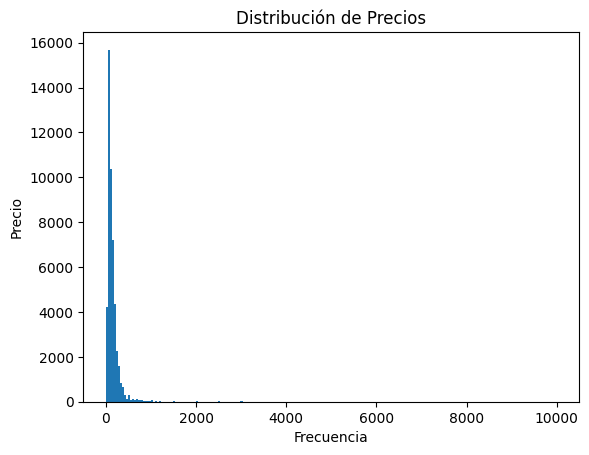

In [6]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.

plt.hist(df['price'], bins=221)

plt.title('Distribución de Precios')
plt.xlabel('Frecuencia')
plt.ylabel('Precio')
plt.show()


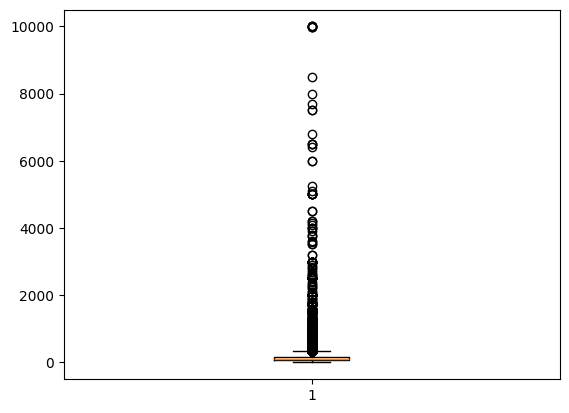

In [7]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).

plt.boxplot(df['price'])
plt.show()


**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_ Los outliers son visibles en todos los graficos, solo seria saber como interpretarlos pero considero que es mas notable en 4.1 o 4.2, 4.3 puede ser confuso y muy "agrupado". Tomando en cuenta la asimetria y curtosis, esta podria afectar como se ve en los graficos (10000 esta llegando hasta 15000 y no hay ningun valor como tal, una distorsion que desfigura el "corazon" de los datos), aunque se pueda ajustar para que se vea bien si es aplicado en machine learning tendra errores catastroficos ya que se tratara de adaptarse a valores cercanos de 10000 lo que dejara de lado el 99% de los datos.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_ Usando el IQR y uno de los graficos (4.1 o 4.2) le explicaria sobre el outlier y como afecta los resultados, incluso mostrar ambas medidas sin el outlier para que viera que tanto afecta el resultado.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |